# Employee Insurance Enrollment  EDA

This notebook explores the synthetic employee enrollment dataset before modeling. The goal is to understand data quality, target balance, feature distributions, and early signals that may help predict whether an employee enrolls in the voluntary insurance product.



In [3]:
# import lib 
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

In [4]:
# configure visualisation

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)

In [5]:
# configure path 
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "employee_data.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH

WindowsPath('d:/Projects/insurance-enrollment-prediction/data/raw/employee_data.csv')

## Load data 

In [7]:
df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.head(10)

Rows: 10,000
Columns: 10


,employee_id,age,gender,marital_status,salary,employment_type,region,has_dependents,tenure_years,enrolled
0,10001,60,Female,Single,55122.97,Part-time,West,No,1.50,0
1,10002,50,Female,Single,89549.66,Full-time,West,Yes,12.80,1
2,10003,36,Male,Divorced,74145.66,Part-time,Midwest,No,3.80,0
3,10004,64,Female,Married,53877.83,Full-time,Northeast,No,3.30,0
4,10005,29,Male,Single,63404.63,Contract,Midwest,Yes,10.00,0
5,10006,42,Male,Married,66274.58,Contract,West,Yes,1.00,1
6,10007,60,Male,Divorced,63415.31,Full-time,South,Yes,3.30,1
7,10008,40,Male,Married,60616.13,Full-time,West,No,3.10,1
8,10009,44,Female,Single,83459.03,Full-time,South,Yes,0.30,1
9,10010,32,Male,Divorced,72926.06,Part-time,South,No,10.80,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   employee_id      10000 non-null  int64  
 1   age              10000 non-null  int64  
 2   gender           10000 non-null  object 
 3   marital_status   10000 non-null  object 
 4   salary           10000 non-null  float64
 5   employment_type  10000 non-null  object 
 6   region           10000 non-null  object 
 7   has_dependents   10000 non-null  object 
 8   tenure_years     10000 non-null  float64
 9   enrolled         10000 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 781.4+ KB


In [8]:
df.describe()

,employee_id,age,salary,tenure_years,enrolled
count,10000.00,10000.00,10000.00,10000.00,10000.00
mean,15000.50,43.00,65032.97,3.97,0.62
std,2886.90,12.29,14923.96,3.90,0.49
min,10001.00,22.00,2207.79,0.00,0.00
25%,12500.75,33.00,54714.34,1.20,0.00
50%,15000.50,43.00,65056.05,2.80,1.00
75%,17500.25,54.00,75053.69,5.60,1.00
max,20000.00,64.00,120312.00,36.00,1.00


## Dataset overview

In [15]:
df.columns.tolist()

['employee_id',
 'age',
 'gender',
 'marital_status',
 'salary',
 'employment_type',
 'region',
 'has_dependents',
 'tenure_years',
 'enrolled']

In [16]:
required_columns = [
    "employee_id",
    "age",
    "gender",
    "marital_status",
    "salary",
    "employment_type",
    "region",
    "has_dependents",
    "tenure_years",
    "enrolled",
]

missing_required = sorted(set(required_columns) - set(df.columns))
print("Missing required columns:", missing_required if missing_required else "None")
print("Duplicate employee_id rows:", df["employee_id"].duplicated().sum())
print("Fully duplicated rows:", df.duplicated().sum())

quality_summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_rate": df.isna().mean(),
        "unique_values": df.nunique(),
    }
)
quality_summary

Missing required columns: None
Duplicate employee_id rows: 0
Fully duplicated rows: 0


,dtype,missing_count,missing_rate,unique_values
employee_id,int64,0,0.00,10000
age,int64,0,0.00,43
gender,object,0,0.00,3
marital_status,object,0,0.00,4
salary,float64,0,0.00,9988
employment_type,object,0,0.00,3
region,object,0,0.00,4
has_dependents,object,0,0.00,2
tenure_years,float64,0,0.00,241
enrolled,int64,0,0.00,2


## Target Distribution

In [17]:
target_summary = (
    df["enrolled"]
    .value_counts()
    .rename_axis("enrolled")
    .reset_index(name="count")
)
target_summary["rate"] = target_summary["count"] / len(df)
target_summary

,enrolled,count,rate
0,1,6174,0.62
1,0,3826,0.38


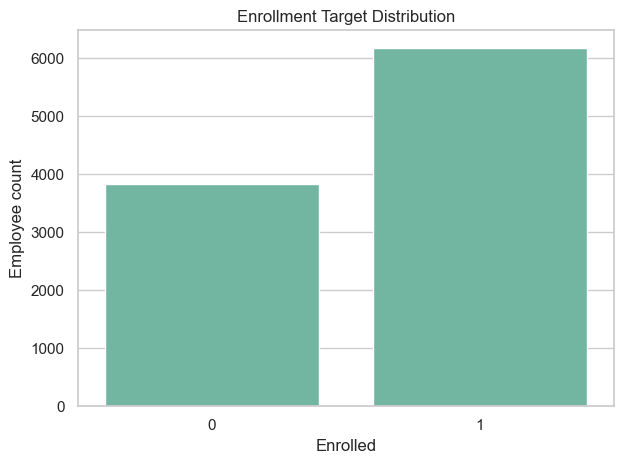

In [18]:
ax = sns.countplot(data=df, x="enrolled")
ax.set_title("Enrollment Target Distribution")
ax.set_xlabel("Enrolled")
ax.set_ylabel("Employee count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "target_distribution.png", dpi=150)
plt.show()

## Numeric Data  analysis


In [19]:
numeric_features = ["age", "salary", "tenure_years"]

df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,10000.00,43.00,12.29,22.00,33.00,43.00,54.00,64.00
salary,10000.00,65032.97,14923.96,2207.79,54714.34,65056.05,75053.69,120312.00
tenure_years,10000.00,3.97,3.90,0.00,1.20,2.80,5.60,36.00


In [20]:
df.groupby("enrolled")[numeric_features].agg(["mean", "median", "std"]).round(2)

age                salary                   tenure_years         \
          mean median   std     mean   median      std         mean median   
enrolled                                                                     
0        38.81  37.00 12.91 58087.02 56407.88 14350.89         4.00   2.80   
1        45.60  46.00 11.11 69337.34 69396.62 13591.27         3.94   2.80   

               
          std  
enrolled       
0        3.90  
1        3.89

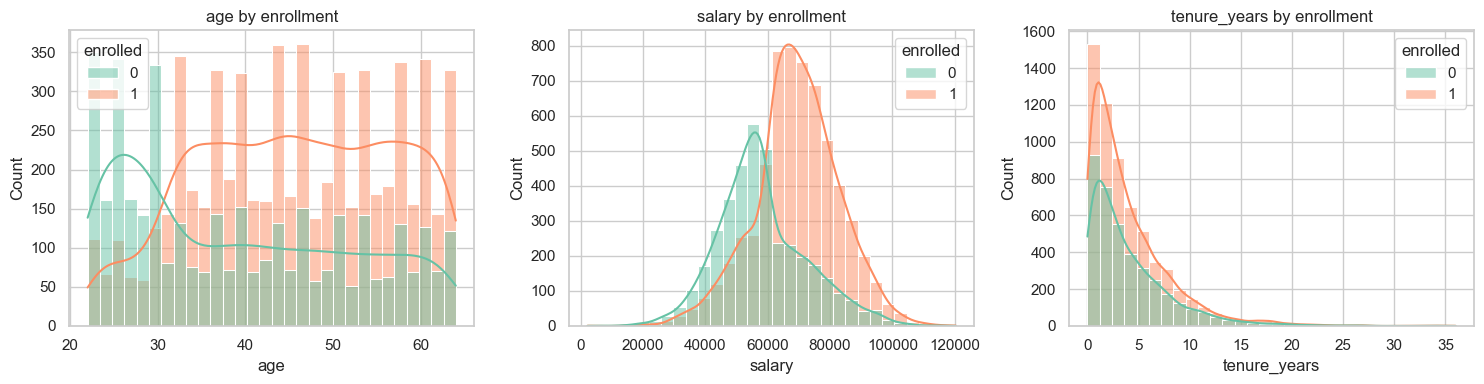

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes, numeric_features):
    sns.histplot(data=df, x=feature, hue="enrolled", kde=True, bins=30, ax=ax)
    ax.set_title(f"{feature} by enrollment")
    ax.set_xlabel(feature)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "numeric_distributions_by_target.png", dpi=150)
plt.show()

## Categorical Feature analysis 

In [22]:
categorical_features = [
    "gender",
    "marital_status",
    "employment_type",
    "region",
    "has_dependents",
]

for feature in categorical_features:
    display(df[feature].value_counts().rename_axis(feature).reset_index(name="count"))


,gender,count
0,Male,4815
1,Female,4810
2,Other,375


,marital_status,count
0,Married,4589
1,Single,3877
2,Divorced,1001
3,Widowed,533


,employment_type,count
0,Full-time,7041
1,Part-time,1973
2,Contract,986


,region,count
0,West,2582
1,Northeast,2506
2,Midwest,2488
3,South,2424


,has_dependents,count
0,Yes,5993
1,No,4007


In [23]:
def enrollment_rate_by_feature(data, feature):
    return (
        data.groupby(feature)["enrolled"]
        .agg(count="count", enrollment_rate="mean")
        .sort_values("enrollment_rate", ascending=False)
        .assign(enrollment_rate=lambda x: x["enrollment_rate"].round(3))
    )


for feature in categorical_features:
    print(f"\nEnrollment rate by {feature}")
    display(enrollment_rate_by_feature(df, feature))


Enrollment rate by gender


,count,enrollment_rate
gender,,
Other,375,0.64
Male,4815,0.62
Female,4810,0.62



Enrollment rate by marital_status


,count,enrollment_rate
marital_status,,
Single,3877,0.63
Widowed,533,0.62
Married,4589,0.61
Divorced,1001,0.60



Enrollment rate by employment_type


,count,enrollment_rate
employment_type,,
Full-time,7041,0.75
Contract,986,0.31
Part-time,1973,0.28



Enrollment rate by region


,count,enrollment_rate
region,,
South,2424,0.63
Midwest,2488,0.62
West,2582,0.61
Northeast,2506,0.61



Enrollment rate by has_dependents


,count,enrollment_rate
has_dependents,,
Yes,5993,0.80
No,4007,0.35


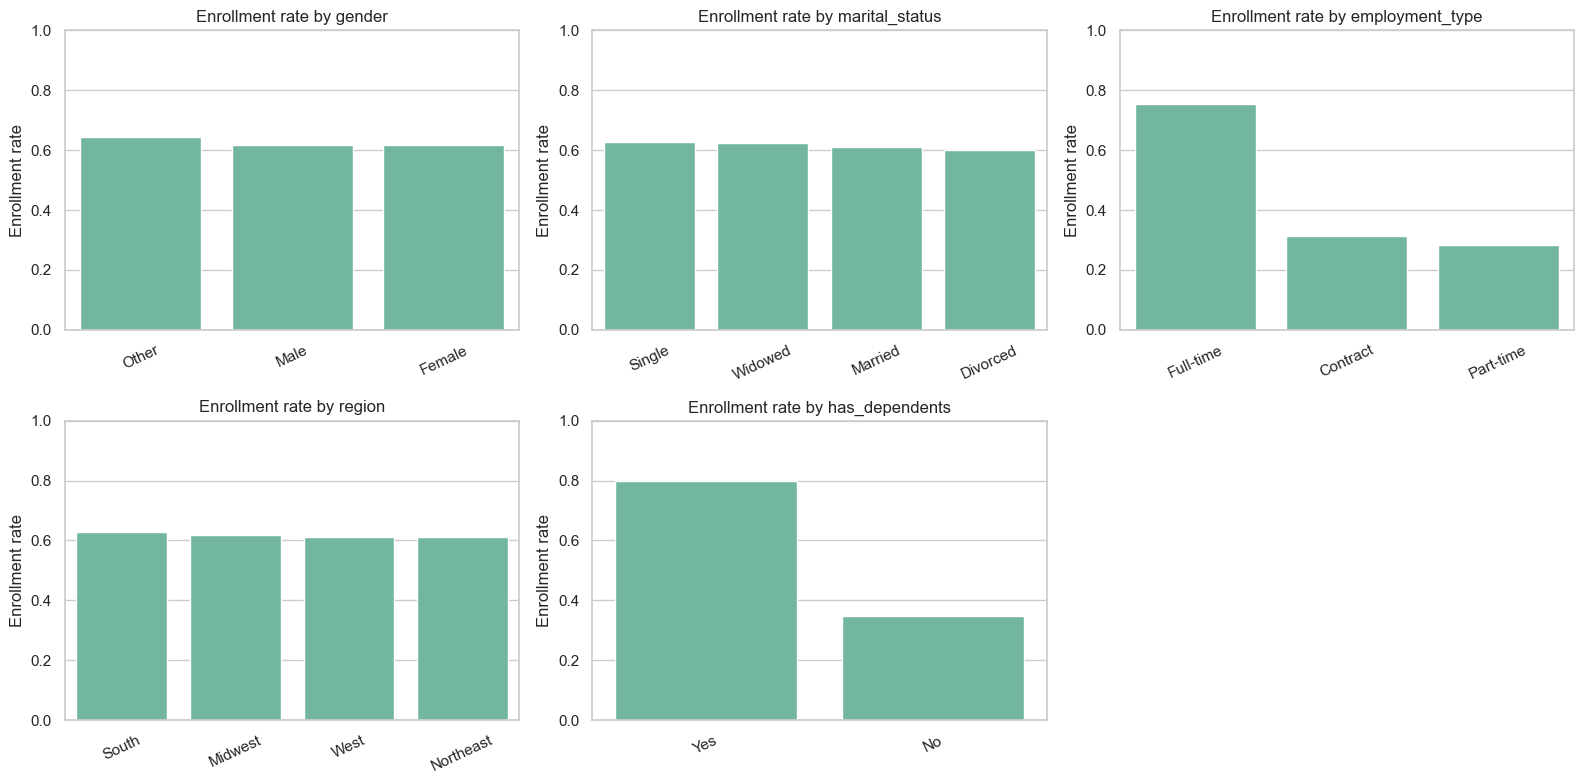

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, feature in zip(axes, categorical_features):
    rates = enrollment_rate_by_feature(df, feature).reset_index()
    sns.barplot(data=rates, x=feature, y="enrollment_rate", ax=ax)
    ax.set_title(f"Enrollment rate by {feature}")
    ax.set_xlabel("")
    ax.set_ylabel("Enrollment rate")
    ax.tick_params(axis="x", rotation=25)
    ax.set_ylim(0, 1)

axes[-1].axis("off")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "categorical_enrollment_rates.png", dpi=150)
plt.show()

## interaction analysis

In [25]:
interaction_summary = (
    df.groupby(["employment_type", "has_dependents"])["enrolled"]
    .agg(count="count", enrollment_rate="mean")
    .reset_index()
)
interaction_summary["enrollment_rate"] = interaction_summary["enrollment_rate"].round(3)
interaction_summary

,employment_type,has_dependents,count,enrollment_rate
0,Contract,No,369,0.00
1,Contract,Yes,617,0.50
2,Full-time,No,2828,0.49
3,Full-time,Yes,4213,0.93
4,Part-time,No,810,0.00
5,Part-time,Yes,1163,0.48


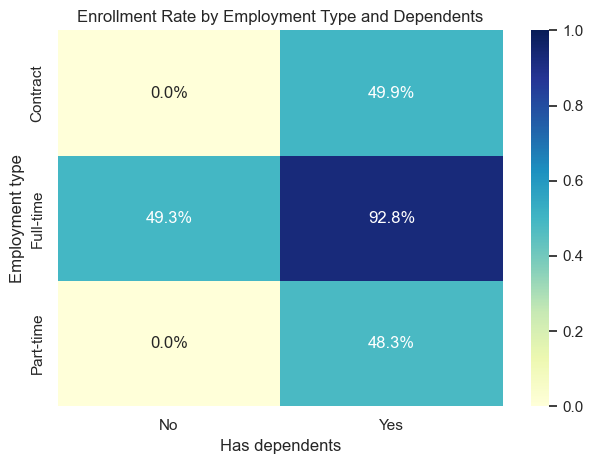

In [26]:
pivot_rates = interaction_summary.pivot(
    index="employment_type",
    columns="has_dependents",
    values="enrollment_rate",
)

ax = sns.heatmap(pivot_rates, annot=True, fmt=".1%", cmap="YlGnBu", vmin=0, vmax=1)
ax.set_title("Enrollment Rate by Employment Type and Dependents")
ax.set_xlabel("Has dependents")
ax.set_ylabel("Employment type")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "employment_dependents_heatmap.png", dpi=150)
plt.show()

## Correlation analysis

In [27]:
correlation = df[["age", "salary", "tenure_years", "enrolled"]].corr(numeric_only=True)
correlation

,age,salary,tenure_years,enrolled
age,1.00,0.00,0.00,0.27
salary,0.00,1.00,-0.00,0.37
tenure_years,0.00,-0.00,1.00,-0.01
enrolled,0.27,0.37,-0.01,1.00


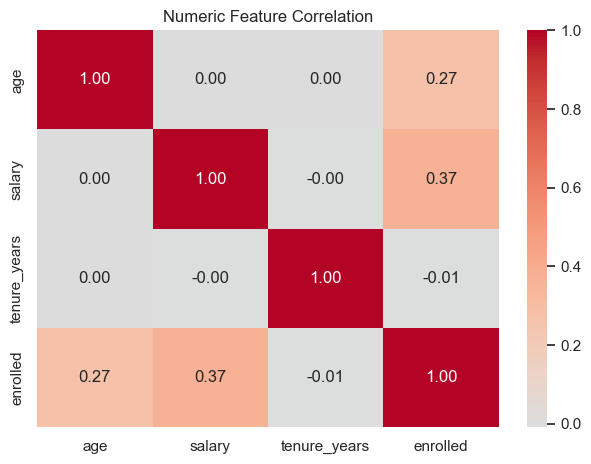

In [28]:
ax = sns.heatmap(correlation, annot=True, cmap="coolwarm", center=0, fmt=".2f")
ax.set_title("Numeric Feature Correlation")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "numeric_correlation_heatmap.png", dpi=150)
plt.show()

  ## EDA Summary and Key Findings

The dataset contains 10,000 employee records and 10 features,   representing demographic and employment characteristics used to  predict voluntary insurance enrollment. The target variable,  enrolled, is binary, with 6,174 employees (61.7%) not enrolled and 3,826 employees (38.3%) enrolled. This represents moderate class imbalance, which should be considered when selecting evaluation metrics and interpreting model performance

  ### Data Quality

The dataset is structurally clean. All expected columns are present, there are no missing values, no duplicate employee_id values, and no fully duplicated rows. The dataset contains three numerical predictors (age, salary, tenure_years) and five categorical predictors (gender, marital_status, employment_type, region, and has_dependents), in addition to the identifier and target columns.

employee_id has 10,000 unique values and should be excluded from model training because it is an identifier rather than a meaningful predictive feature

 ### Numerical Features

The numerical variables have the following distributions:

Age: mean of 43 years, ranging from 22 to 64.

Salary: mean of approximately 65,033, with a relatively wide range from approximately 2,208 to 120,312.

Tenure: mean of approximately 3.97 years, ranging from 0 to 36 years. fileciteturn1file0L825-L856

The correlation analysis shows that salary has the strongest linear association with enrollment (r = 0.37), followed by age (r = 0.27). Tenure has almost no linear correlation with enrollment (r = -0.01). The numerical predictors also show essentially no correlation with each other, suggesting limited multicollinearity among these variables. 

### Categorical Features

Gender shows very little difference in enrollment rates: both Male and Female employees have an enrollment rate of approximately 62%, while the smaller Other category has a rate of approximately 64%

Marital status also shows relatively small differences, with enrollment rates ranging from approximately 60% to 63% across categories. This suggests that marital status is unlikely to be a dominant standalone predictor. 

Regional differences are similarly limited. Enrollment rates range from approximately 61% to 63% across the four regions, indicating relatively weak standalone geographic effects in this dataset.

employment type shows a substantial relationship with enrollment:

Full-time: 75%

Contract: 31%

Part-time: 28% 

The strongest categorical relationship is observed for having dependents:

Employees with dependents: 80% enrollment

Employees without dependents: 35% enrollment 

### Interaction Analysis

The interaction between employment type and dependent status reveals an even stronger pattern

